In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Matplotlib is building the font cache; this may take a moment.


In [7]:
solar_data = pd.read_csv('/Users/starl/Downloads/SOLAR_PLANT_DATA(GENERATION_AND_WEATHER).csv')

solar_data.iloc[10:30]

,DATE_TIME,PLANT_ID,IRRADIATION,AMBIENT_TEMPERATURE,DC_EFFICIENCY,AC_EFFICIENCY,INVERTOR_EFFICIENCY,YIELD_INDEX,TRUE_DAILY_YIELD
10,2020-05-15 02:30:00,4136001,0.000000,26.260399,0.000000,0.000000,0.000000,0.000000,0.000000
11,2020-05-15 02:45:00,4136001,0.000000,26.297826,0.000000,0.000000,0.000000,0.000000,0.000000
12,2020-05-15 03:00:00,4136001,0.000000,26.328249,0.000000,0.000000,0.000000,0.000000,0.000000
13,2020-05-15 03:15:00,4136001,0.000000,26.158710,0.000000,0.000000,0.000000,0.000000,0.000000
14,2020-05-15 03:30:00,4136001,0.000000,26.078499,0.000000,0.000000,0.000000,0.000000,0.000000
15,2020-05-15 03:45:00,4136001,0.000000,26.001304,0.000000,0.000000,0.000000,0.000000,0.000000
16,2020-05-15 04:00:00,4136001,0.000000,25.697211,0.000000,0.000000,0.000000,0.000000,0.000000
17,2020-05-15 04:15:00,4136001,0.000000,25.627702,0.000000,0.000000,0.000000,0.000000,0.000000
18,2020-05-15 04:30:00,4136001,0.000000,25.482046,0.000000,0.000000,0.000000,0.000000,0.000000
19,2020-05-15 04:45:00,4136001,0.000000,25.230932,0.000000,0.000000,0.000000,0.000000,0.000000


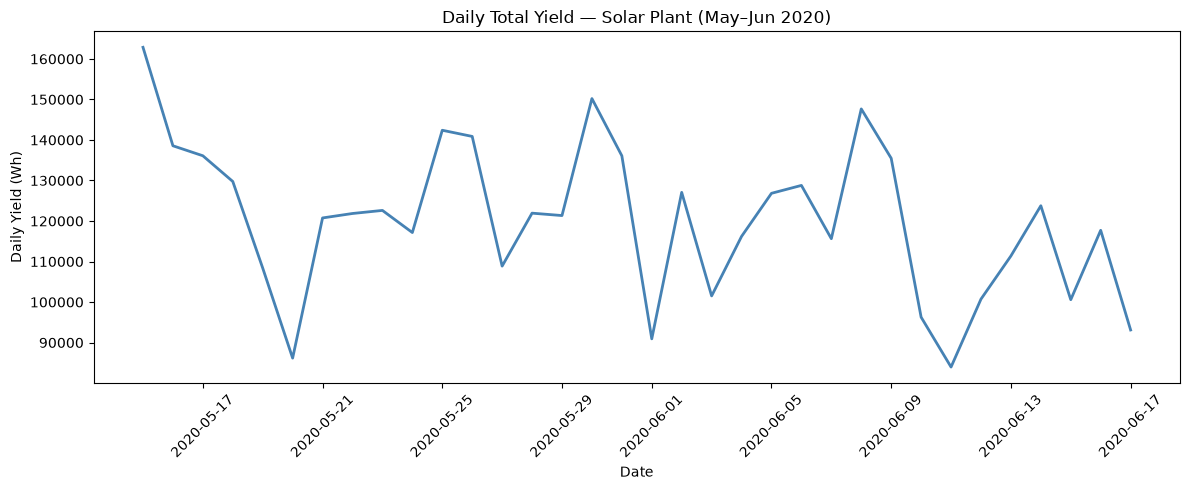

In [8]:
# Matplotlib line chart showing daily total yield over the 34 day period
solar_data['DATE_TIME'] = pd.to_datetime(solar_data['DATE_TIME'])

daily = solar_data.groupby(solar_data['DATE_TIME'].dt.date)['TRUE_DAILY_YIELD'].max()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=2)
plt.title('Daily Total Yield — Solar Plant (May–Jun 2020)')
plt.xlabel('Date')
plt.ylabel('Daily Yield (Wh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

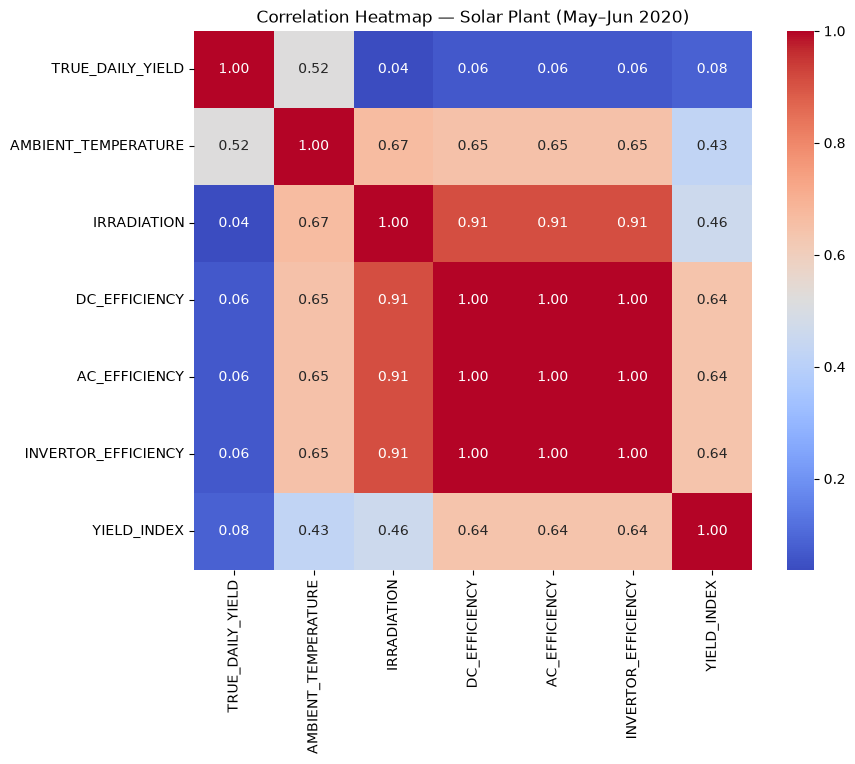

<Figure size 640x480 with 0 Axes>

In [9]:
# Seaborn correlation heatmap showing relationships between all variables
# 1 means when one variable goes up, the other goes up
# -1 means when one goes up, the other goes down
# 0 means little to no relationship between factors

plt.figure(figsize=(9, 7))
sns.heatmap(solar_data[['TRUE_DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'IRRADIATION', 'DC_EFFICIENCY', 'AC_EFFICIENCY', 'INVERTOR_EFFICIENCY', 'YIELD_INDEX']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap — Solar Plant (May–Jun 2020)')
plt.show()
plt.tight_layout()
plt.show()

In [10]:
# Plotly interactive scatter plot of irradiation vs daily yield colored by temperature
fig = px.scatter(solar_data,
                 x='IRRADIATION',
                 y='TRUE_DAILY_YIELD',
                 color='AMBIENT_TEMPERATURE',
                 title='Irradiation vs Daily Yield — Solar Plant',
                 labels={'IRRADIATION': 'Irradiation (kW/m²)',
                         'TRUE_DAILY_YIELD': 'Daily Yield (Wh)',
                         'AMBIENT_TEMPERATURE': 'Ambient Temp (°C)'})
fig.show()